In [6]:
!pip install sentence-transformers

In [7]:
sentences = [
    # Cricket
    "The bowler took three wickets in one over.",
    "The batsman scored a century in the match.",
    "The team won the cricket tournament.",
    "The captain set an aggressive field.",

    # Cooking
    "I cooked pasta for dinner.",
    "The recipe requires fresh vegetables.",
    "Baking a cake requires patience.",

    # Cybersecurity
    "Cybersecurity protects systems from hackers.",
    "Strong passwords improve security.",
    "Encryption keeps data safe."
]

print(len(sentences))

10


In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


[[ 1.          0.57997596  0.5637473   0.21457574  0.12509704  0.09056455
   0.04800908  0.02344224  0.05375217 -0.00527229]
 [ 0.57997596  1.0000002   0.5670228   0.2526953  -0.02246615  0.07347412
   0.02409838 -0.00289654 -0.01699653 -0.0509556 ]
 [ 0.5637473   0.5670228   1.0000001   0.1527001   0.00515059  0.08879986
   0.04944645  0.03527999 -0.00307354  0.00790446]
 [ 0.21457574  0.2526953   0.1527001   1.         -0.00971227 -0.01517602
  -0.05252449  0.03683583  0.04650356 -0.04912146]
 [ 0.12509704 -0.02246615  0.00515059 -0.00971227  1.0000002   0.27611512
   0.14820492  0.036413   -0.0046016   0.06420773]
 [ 0.09056455  0.07347412  0.08879986 -0.01517602  0.27611512  1.
   0.24496852 -0.07733278 -0.001728    0.02654567]
 [ 0.04800908  0.02409838  0.04944645 -0.05252449  0.14820492  0.24496852
   1.0000001  -0.01733674  0.04315384  0.06403823]
 [ 0.02344224 -0.00289654  0.03527999  0.03683583  0.036413   -0.07733278
  -0.01733674  1.          0.51059586  0.4264549 ]
 [ 0.053

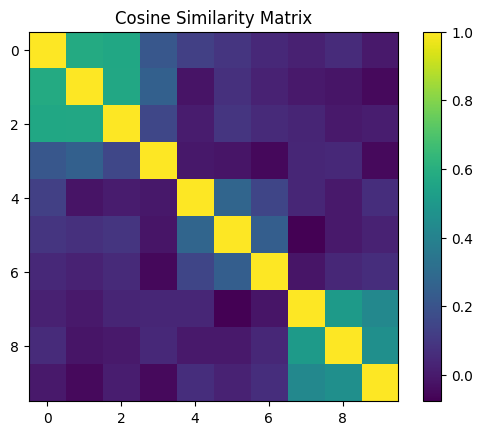

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

plt.imshow(similarity_matrix)
plt.colorbar()
plt.title("Cosine Similarity Matrix")
plt.show()

In [10]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

for idx in top_indices:
    print(sentences[idx], "->", similarities[idx])

The bowler took three wickets in one over. -> 0.9913637
The batsman scored a century in the match. -> 0.56114495
